In [ ]:
#13-11-25
#RH=100 case
#Mass-weighted random sampling
#for ht in range(32, 91, 9).

import time
overall_start_time = time.time()
import os
import sys

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2025 Nov 13 11:34:54 > Log nicely initialized 
2025 Nov 13 11:34:54 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2025 Nov 13 11:34:54 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001
2025 Nov 13 11:34:54 > (DI0021) Found 8 time-varying files in date range
2025 Nov 13 11:34:54 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2025 Nov 13 11:34:55 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2025 Nov 13 11:34:55 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2025 Nov 13 11:34:55 > (DI0037) Loading horizonta

In [4]:
seed = 1
sample_frac = 0.001 

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac


In [5]:
# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
for ht in range(32, 91, 9): #(32, 91, 9)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)

# print('length of dfs: ',len(dfs))
# print('len of dfs[0]: ', len(dfs[0]))
prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

Last value of clon in df with height 32 is 1.3343108942333097
Last value of clon in df with height 41 is 1.3343108942333097
Last value of clon in df with height 50 is 1.3343108942333097
Last value of clon in df with height 59 is 1.3343108942333097
Last value of clon in df with height 68 is 1.3343108942333097
Last value of clon in df with height 77 is 1.3343108942333097
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  167772160
Final length of df:  167772160


In [6]:
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
# print('df after threshold-2:\n', df)

In [7]:
#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

In [8]:
df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

In [9]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("incorrect count = ", count)
print("incorrect count percent = ", 100*count/len(df['RH']))

incorrect count =  551244
incorrect count percent =  1.5098937532694179


In [10]:
df['RH']= df['RH'].clip(lower=0, upper=100)

In [11]:
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 15th position
df.pop('hus')

df['clw+cli']=df['clw']+df['cli']

col=df.pop('clw+cli')
df.insert(25, 'clw+cli', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)'],
      dtype='object')

In [12]:
#Include 'cloud liquid water path + cloud ice path' as a feature.

df['cllvi+clivi']=df['cllvi']+df['clivi']

col=df.pop('cllvi+clivi')
df.insert(26, 'cllvi+clivi', col) 

# df.to_csv("df.csv", index=False)
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [13]:
# m_ci_j=dzghalf*rho*cell_area*(clw+cli)
df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

col=df.pop('m_ci')
df.insert(27, 'm_ci', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [14]:
df = df.sort_values(by='m_ci', ascending=False)
df

,clon,clat,cell_area,pr,tas,clivi,cllvi,qgvi,qrvi,qsvi,...,height,height_2,clw+cli,cllvi+clivi,m_ci,clw/(clw+cli),cli/(clw+cli),qr/(qr+qs+qg),qs/(qr+qs+qg),qg/(qr+qs+qg)
117861069,-0.771414,-0.256888,2.379056e+07,3.854987e-03,NaN,3.889840e-01,1.293985e+01,4.127268e+00,2.688075e+00,3.530294,...,68.0,68.0,0.005415,1.332883e+01,3.310177e+07,1.0,2.284979e-08,2.987168e-01,5.462509e-01,1.550322e-01
117861059,-0.770835,-0.257218,2.378392e+07,1.323980e-02,NaN,3.649554e-01,8.942155e+00,1.231057e+00,7.239639e+00,3.152875,...,68.0,68.0,0.005309,9.307110e+00,3.249557e+07,1.0,2.979694e-08,9.887701e-01,6.368610e-03,4.861287e-03
118028384,-1.321747,-0.153975,2.519453e+07,4.917022e-03,NaN,1.866462e-01,6.484782e+00,9.399114e-01,8.904063e-01,3.343819,...,68.0,68.0,0.005038,6.671428e+00,3.217215e+07,1.0,7.001205e-08,9.999993e-01,7.103275e-07,1.101566e-08
120350292,1.249436,-0.063023,2.527334e+07,1.599252e-02,NaN,4.941337e-02,9.415250e+00,2.862154e-02,5.029284e+00,0.056373,...,68.0,68.0,0.004583,9.464664e+00,3.174046e+07,1.0,2.999548e-08,9.500117e-01,2.542847e-02,2.455981e-02
118029299,-1.309986,-0.164801,2.519648e+07,1.278854e-02,NaN,9.988518e-04,9.142307e+00,1.120025e-01,2.258600e+00,0.000234,...,68.0,68.0,0.004665,9.143306e+00,3.088686e+07,1.0,1.441872e-09,6.742199e-01,3.447822e-07,3.257797e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107567033,-2.909210,0.825527,2.466639e+07,-6.531162e-10,NaN,1.815684e-12,7.418235e-02,1.015835e-12,9.210621e-06,0.000177,...,68.0,68.0,0.000000,7.418235e-02,0.000000e+00,0.0,0.000000e+00,1.322457e-10,1.000000e+00,2.470640e-28
99620630,0.345718,-0.710992,2.449968e+07,5.145258e-17,NaN,1.080184e-07,1.648928e-02,2.332524e-05,2.044353e-09,0.000356,...,59.0,59.0,0.000000,1.648939e-02,0.000000e+00,0.0,0.000000e+00,2.899201e-11,9.998241e-01,1.758785e-04
92109491,-1.324444,0.408916,2.486895e+07,1.549578e-16,NaN,3.327972e-12,1.588766e-08,2.365204e-12,1.278172e-13,0.000681,...,59.0,59.0,0.000000,1.589099e-08,0.000000e+00,0.0,0.000000e+00,2.524809e-11,1.000000e+00,9.971311e-24
106876434,3.078205,0.631400,2.324060e+07,-2.018271e-10,NaN,1.137726e-04,4.908991e-06,1.778243e-01,2.935887e-03,0.009215,...,68.0,68.0,0.000000,1.186816e-04,0.000000e+00,0.0,0.000000e+00,5.606506e-12,7.095240e-01,2.904760e-01


In [15]:
df = df.reset_index(drop=True)
df['m_ci']

0           3.310177e+07
1           3.249557e+07
2           3.217215e+07
3           3.174046e+07
4           3.088686e+07
                ...     
36508789    0.000000e+00
36508790    0.000000e+00
36508791    0.000000e+00
36508792    0.000000e+00
36508793    0.000000e+00
Name: m_ci, Length: 36508794, dtype: float64

In [16]:
total_mass = df['m_ci'].sum()
total_mass #kg

np.float64(6506367837186.283)

In [17]:
df['cum_mass'] = df['m_ci'].cumsum()

col=df.pop('cum_mass')
df.insert(28, 'cum_mass', col) 

df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'clw/(clw+cli)', 'cli/(clw+cli)',
       'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [18]:
#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(29, 'qr+qg+qs', col)

df.columns


Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [19]:
n_samples= int(np.floor(len(df) * 0.1))

np.random.seed(29)

random_values = np.random.uniform(0, total_mass, size=n_samples)

print('Random values: ', random_values)

indices= np.searchsorted(df['cum_mass'].values, random_values)

df_orig=df

df = df.iloc[indices].reset_index(drop=True)

Random values:  [5.61994019e+12 1.85370301e+12 4.76633007e+11 ... 4.50113919e+12
 4.92267281e+12 6.41732042e+12]


In [21]:
#RH<100
df['RH']

0          100.000000
1           99.531624
2           99.483421
3          100.000000
4           99.129196
              ...    
3650874     99.290031
3650875     99.070107
3650876     99.267593
3650877     99.630386
3650878     70.520355
Name: RH, Length: 3650879, dtype: float32

In [28]:
df_RH_equal_to_100 = df[df['RH']==100] 
df_RH_equal_to_100['RH']

percent_data_RH_equal_to_100 = 100*len(df_RH_equal_to_100)/len(df)
percent_data_RH_equal_to_100 

5.106824959139977

In [25]:
df_RH_greater_than_100 = df[df['RH']>100] 
df_RH_greater_than_100['RH']

Series([], Name: RH, dtype: float32)

In [27]:
df_RH_less_than_100 = df[df['RH']<100] 
df_RH_less_than_100['RH']

percent_data_RH_less_than_100 = 100*len(df_RH_less_than_100)/len(df)
percent_data_RH_less_than_100 

94.89317504086003

In [30]:
df= df_RH_equal_to_100

In [32]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [33]:
#overall MLR code
X = df.iloc[:, [1,15,16,17,20,21,22,25,26,29]].values #15 is RH (turn it on/off), 
y = df.iloc[:, [-5]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
cols= [1,15,16,17,20,21,22,25,26,29]
feature_names=df.columns[cols].tolist()

from sklearn import linear_model

regr=linear_model.LinearRegression()
regr.fit(X_train,y_train)

y_predicted = regr.predict(X_test)
y_predicted = np.clip(y_predicted, 0, 1)

#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_predicted)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_predicted)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_predicted))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_predicted)
print("R² score:", r2_sklearn)

#Coefficient
coef_list= regr.coef_[0]

coef_table = pd.DataFrame(
{
    'Feature': feature_names,
    'Coefficient': coef_list
}
)

#Sort by absolute coeff val

coef_table['abs(Coefficient)'] = coef_table['Coefficient'].abs()
coef_table.sort_values(by='abs(Coefficient)', ascending=False, inplace=True)
print(coef_table)


MSE_TEST: 5.1412545288056714e-05
RMSE_TEST: 0.007170254199681955
mae_TEST: 0.0012696649260256012
R² score: 0.06786458445100596
       Feature   Coefficient  abs(Coefficient)
7      clw+cli  1.220157e+00      1.220157e+00
9     qr+qg+qs  1.165138e+00      1.165138e+00
3           wa -1.396058e-03      1.396058e-03
0         clat -1.041527e-03      1.041527e-03
8  cllvi+clivi  2.315273e-04      2.315273e-04
2           ta  1.725721e-04      1.725721e-04
5           va  3.698640e-05      3.698640e-05
4           ua -8.564811e-06      8.564811e-06
6        pfull  1.487876e-08      1.487876e-08
1           RH -1.518753e-14      1.518753e-14


In [34]:
pairs = [(name, abs(coef)) for name, coef in zip(feature_names, coef_list)]
pairs.sort(key=lambda x: x[1], reverse=True)

for name, coef in pairs:
    print(f"{name}:{coef:.6f}")


clw+cli:1.220157
qr+qg+qs:1.165138
wa:0.001396
clat:0.001042
cllvi+clivi:0.000232
ta:0.000173
va:0.000037
ua:0.000009
pfull:0.000000
RH:0.000000


In [21]:
# import seaborn as sns

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=y_test.flatten(), y=y_predicted.flatten(), alpha=0.7)
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
# plt.title("Actual vs Predicted Values (MLR)")
# # Add a perfect prediction line
# plt.plot([y_test.min(), y_test.max()],
#          [y_test.min(), y_test.max()],
#          color='red', lw=2)
# plt.show()


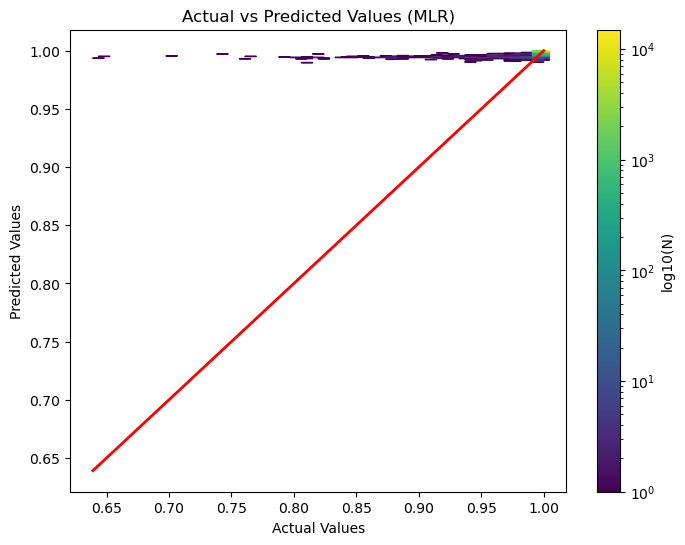

In [35]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_predicted.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (MLR)")
plt.show()


In [36]:
#ft 16 ('RH') and -5 ('clw/(clw+cli)')
df['RH']


0          100.0
3          100.0
19         100.0
33         100.0
40         100.0
           ...  
3650742    100.0
3650791    100.0
3650847    100.0
3650858    100.0
3650866    100.0
Name: RH, Length: 186444, dtype: float32

In [37]:
df['clw/(clw+cli)']

0          1.000000
3          1.000000
19         0.999998
33         1.000000
40         1.000000
             ...   
3650742    1.000000
3650791    0.999949
3650847    1.000000
3650858    1.000000
3650866    1.000000
Name: clw/(clw+cli), Length: 186444, dtype: float32

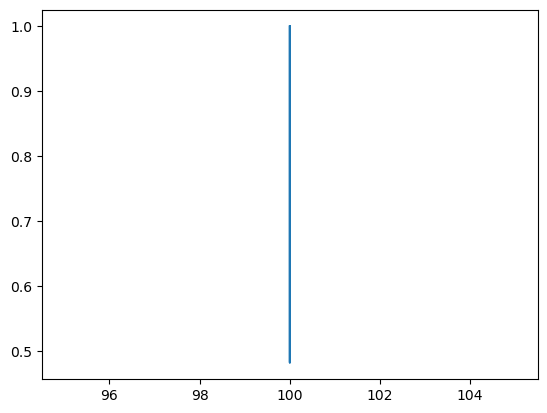

In [38]:
plt.plot(df['RH'], df['clw/(clw+cli)'])

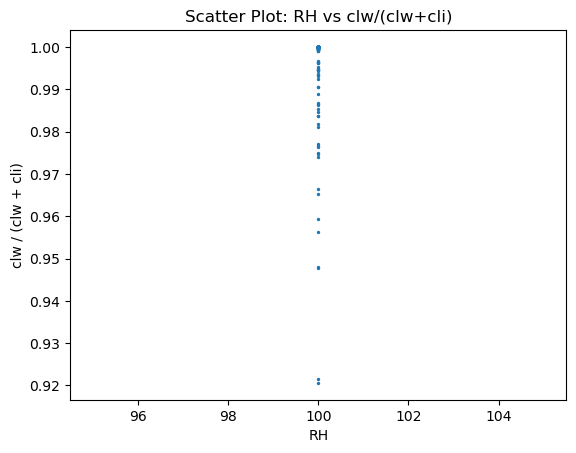

In [39]:
plt.scatter(df['RH'][::100], df['clw/(clw+cli)'][::100], s=2)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Scatter Plot: RH vs clw/(clw+cli)")
plt.show()

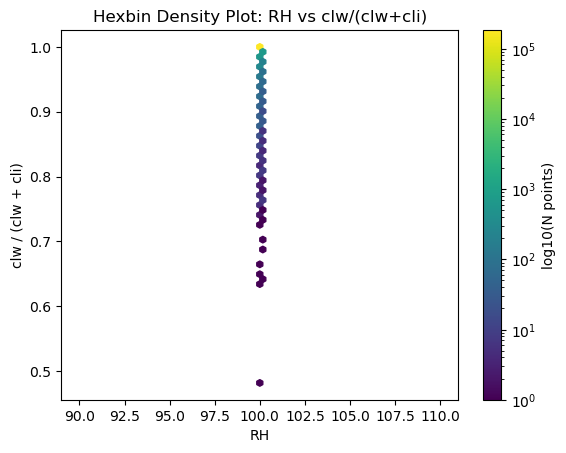

In [42]:
plt.hexbin(
    df['RH'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: RH vs clw/(clw+cli)")
plt.show()


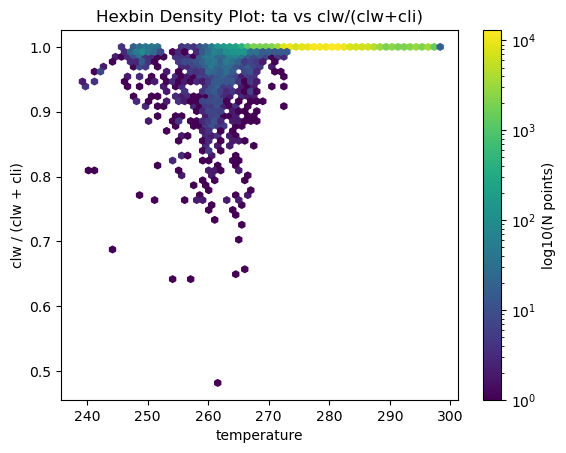

In [43]:
#clw frac v/s ta
plt.hexbin(
    df['ta'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("temperature")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ta vs clw/(clw+cli)")
plt.show()


In [44]:
# print("Description of the df:\n")
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].describe())
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].isna().sum())
# print("Description ends\n")

# split data into X and y
# X = df.iloc[:, [15,16]].values # RH, ta
X = df.iloc[:, [1,15,16,17,20,21,22,25,26,29]].values 

y = df.iloc[:, [-5]].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

cols= [1,15,16,17,20,21,22,25,26,29]
feature_names=df.columns[cols].tolist()
print(feature_names)

['clat', 'RH', 'ta', 'wa', 'ua', 'va', 'pfull', 'clw+cli', 'cllvi+clivi', 'qr+qg+qs']


In [45]:
#This is df and not X_train
print('RH min: ', df['RH'].min())
print('RH max: ', df['RH'].max())
print('\n')
print('ta min: ', df['ta'].min())
print('ta max: ', df['ta'].max())
print('\n')
print('pfull min: ', df['pfull'].min())
print('pfull max: ', df['pfull'].max())
print('\n')
print('wa min: ', df['wa'].min())
print('wa max: ', df['wa'].max())
print('\n')

RH min:  100.0
RH max:  100.0


ta min:  238.75098
ta max:  298.29633


pfull min:  34663.668
pfull max:  99279.43


wa min:  -4.962685
wa max:  4.2083454




In [46]:
print(len(y_train))
print(len(y_test))

149155
37289


Decision Tree

In [ ]:
# #Medium
# #Use Cross-Validation
# #best depth acc. to val data

# train_r2_scores=[]
# val_r2_scores=[]
# depths=range(1,11) #This seemed a reasonable depth range which is obtained from trial and error and articles online
# for depth in depths:
#     tree=DTR(max_depth=depth, random_state=1)
#     #train
#     tree.fit(X_train,y_train)
#     train_score=tree.score(X_train, y_train)
#     train_r2_scores.append(train_score)
#     # print(f"Depth {depth}: Training R2 score = {train_score} ") 

#     #val
    
#     val_scores= cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#     # print(f"Depth {depth}: Mean Validation R2 score = {val_scores.mean()} ") #val_scores.mean(): .4f
#     val_r2_scores.append(val_scores.mean())

# #print(type(val_scores)) #<class 'numpy.ndarray'>
# #print(val_scores)
# max_val_r2_score=max(val_r2_scores)
# bestDepth=depths[val_r2_scores.index(max_val_r2_score)]
# print(f"\nMax. Validation R2 score: {max_val_r2_score} is at depth (bestDepth): {bestDepth}") #Validation R2 score is different from Test R2 score

# #Plotting
# plt.figure() #figsize=(8,5)
# plt.plot(depths, train_r2_scores, marker='o', label='Training R2')
# plt.plot(depths, val_r2_scores, marker='s', label='Validation R2')
# plt.xlabel("Tree Depth")
# plt.ylabel("R2 score")
# plt.title("Decision Tree Performance vs Depth")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# #to find the best Depth and the best number of min samples in leaf
# depths = range(1, 21) #range(1, 21)
# min_samples_in_leaf = range(1, 41) #range(1,51)

# train_r2_scores = []
# val_r2_scores = []
# param_combinations = []

# best_val_score = -np.inf
# best_depth = None
# best_min_samples_leaf = None

# for depth in depths:
#     for min_samples in min_samples_in_leaf:
#         tree = DTR(max_depth=depth, min_samples_leaf=min_samples, random_state=1)

#         tree.fit(X_train, y_train)
#         train_score = tree.score(X_train, y_train)
      
#         val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
#         val_mean = val_scores.mean()
       
#         train_r2_scores.append(train_score)
#         val_r2_scores.append(val_mean)
#         param_combinations.append((depth, min_samples))

#         if val_mean > best_val_score:
#             best_val_score = val_mean
#             best_depth = depth
#             best_min_samples_leaf = min_samples

# print(f"\nBest Validation R2 Score: {best_val_score: }")
# print(f"Best Parameters: max_depth={best_depth}, min_samples_leaf={best_min_samples_leaf}")

# #took 48 mins to run
# #eg: max_depth=14, min_samples_leaf=40

In [ ]:
# param_combinations = np.array(param_combinations)
# depths_arr = param_combinations[:, 0]
# min_samples_arr = param_combinations[:, 1]
# val_r2_scores = np.array(val_r2_scores)


# plt.figure(figsize=(10, 6))
# plt.tricontourf(depths_arr, min_samples_arr, val_r2_scores, levels=20, cmap='viridis')
# plt.colorbar(label="Mean CV (Validation) R2 Score")
# plt.xlabel("Tree Depth")
# plt.ylabel("Min Samples in Leaf")
# plt.title("Decision Tree Cross-Validation Performance Grid Search")
# plt.show()


[Text(0.4778409090909091, 0.9375, 'ta <= 265.0\nsquared_error = 0.0\nsamples = 149155\nvalue = 0.999'),
 Text(0.2863636363636364, 0.8125, 'clw+cli <= 0.0\nsquared_error = 0.002\nsamples = 2583\nvalue = 0.974'),
 Text(0.3821022727272727, 0.875, 'True  '),
 Text(0.1340909090909091, 0.6875, 'qr+qg+qs <= 0.0\nsquared_error = 0.003\nsamples = 895\nvalue = 0.95'),
 Text(0.06363636363636363, 0.5625, 'qr+qg+qs <= 0.0\nsquared_error = 0.0\nsamples = 515\nvalue = 0.979'),
 Text(0.02727272727272727, 0.4375, 'ta <= 258.899\nsquared_error = 0.0\nsamples = 291\nvalue = 0.991'),
 Text(0.01818181818181818, 0.3125, 'squared_error = 0.0\nsamples = 31\nvalue = 0.971'),
 Text(0.03636363636363636, 0.3125, 'qr+qg+qs <= 0.0\nsquared_error = 0.0\nsamples = 260\nvalue = 0.994'),
 Text(0.01818181818181818, 0.1875, 'clat <= 0.94\nsquared_error = 0.0\nsamples = 104\nvalue = 0.997'),
 Text(0.00909090909090909, 0.0625, 'squared_error = 0.0\nsamples = 59\nvalue = 0.998'),
 Text(0.02727272727272727, 0.0625, 'squared_

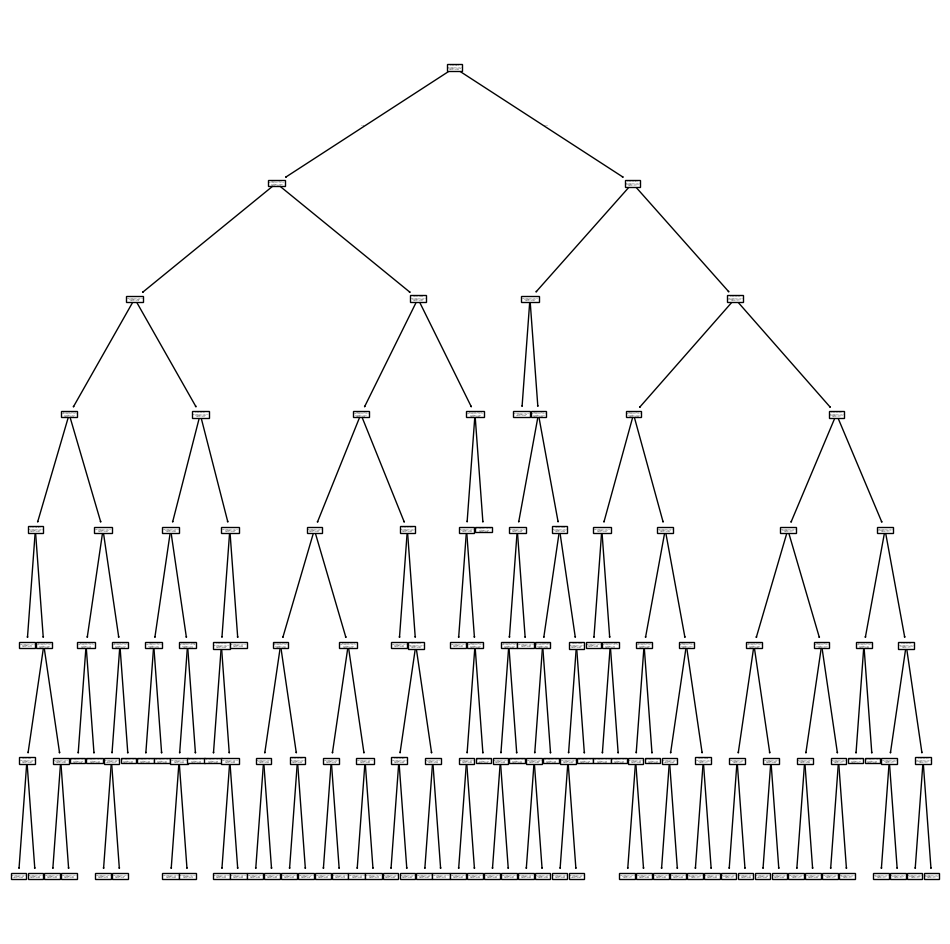

In [47]:
#Pathway-1
best_depth= 7 #14
best_min_samples_leaf=30 #40

reg=DTR(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)
reg.fit(X_train, y_train)
ax=subplots(figsize=(12,12))[1]
plot_tree(reg, feature_names=feature_names, ax=ax)

In [ ]:
#sample

In [48]:
#Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Prediction- Elapsed time: 0.0000 minutes


In [49]:
y_pred

array([0.99999993, 0.99999993, 0.99999993, ..., 0.99999993, 0.99999993,
       0.99999993], shape=(37289,))

In [50]:
y_test

array([[1.       ],
       [1.       ],
       [0.9999998],
       ...,
       [1.       ],
       [1.       ],
       [1.       ]], shape=(37289, 1), dtype=float32)

In [51]:
type(y_test)

numpy.ndarray

In [52]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [53]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score before CCP:", r2_sklearn)

MSE_TEST: 1.5255245839588777e-05
RMSE_TEST: 0.003905796441135761
mae_TEST: 0.00029440480892249535
R² score before CCP: 0.7234146872068891


In [ ]:
# #Check on Sample data

# y_okati=np.array([[1,2],[3,4]])
# y_rendu=np.array([[1.5,3],[4,5]])

# # mse_TEST= np.mean((y_okati- y_rendu)**2)
# # print(f'MSE_TEST: {mse_TEST}')

# r2 = r2_score(y_okati, y_rendu)
# print("R2 score: ", r2)


In [ ]:
#Pathway-1
#This seems more robust because it uses CV and not test data to determine the best ccp_alpha

# ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)

# kfold = skm.KFold(5,
# shuffle=True,
# random_state=10)

# grid = skm.GridSearchCV(reg,
# {'ccp_alpha': ccp_path.ccp_alphas},
# refit=True,
# cv=kfold,
# scoring='r2',
# n_jobs=-1)

# G = grid.fit(X_train, y_train)

# best_ = grid.best_estimator_
# print(best_)

# depth = best_.get_depth()
# print(depth)

In [ ]:
#Pathway-1
#Plot the best tree
# ax= subplots(figsize=(12,12))[1]
# plot_tree(G.best_estimator_, feature_names=feature_names, ax=ax) #after ccp

In [ ]:
# ##Prediction
# prediction_start_time = time.time()
# y_pred = best_.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# #########################################
# print('size of y_pred: ', len(y_pred))

In [54]:
##Prediction
prediction_start_time = time.time()
y_pred = reg.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

#########################################
print('size of y_pred: ', len(y_pred))

Prediction- Elapsed time: 0.0000 minutes
size of y_pred:  37289


In [55]:
y_test  

array([1.       , 1.       , 0.9999998, ..., 1.       , 1.       ,
       1.       ], shape=(37289,), dtype=float32)

In [56]:
y_pred

array([0.99999993, 0.99999993, 0.99999993, ..., 0.99999993, 0.99999993,
       0.99999993], shape=(37289,))

In [57]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score:", r2_sklearn)

MSE_TEST: 1.5255245839588777e-05
RMSE_TEST: 0.003905796441135761
mae_TEST: 0.00029440480892249535
R² score: 0.7234146872068891


In [58]:
# #DT-feature importances in descending order
# importance = best_.feature_importances_
# feature_scores= list(zip(feature_names, importance))
# feature_scores.sort(key=lambda x: x[1], reverse= True)
# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

#DT-feature importances in descending order
importance = reg.feature_importances_
feature_scores= list(zip(feature_names, importance))
feature_scores.sort(key=lambda x: x[1], reverse= True)
for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.401767
qr+qg+qs:0.312169
clw+cli:0.228870
clat:0.028063
cllvi+clivi:0.018900
va:0.009536
wa:0.000444
pfull:0.000251
RH:0.000000
ua:0.000000


In [59]:
print(reg)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=30, random_state=0)


In [60]:
best_ccp_alpha= reg.ccp_alpha
best_ccp_alpha

0.0

Bagging

In [ ]:
#expt with min_sample_leaf = 50, etc. 

In [ ]:
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 ###1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [61]:
#Bagging
ideal_n_trees=100
model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

#Error Analysis on TEST data
#MSE_test
MSE_Test = np.mean((y_test - y_pred)**2)
print(f'MSE_Test: {MSE_Test}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score (sklearn):", r2_sklearn)

Training- Elapsed time: 0.0473 minutes
Prediction- Elapsed time: 0.0009 minutes
MSE_Test: 1.5131588995454544e-05
RMSE_TEST: 0.003889934317627297
mae_TEST: 0.00027187865932052366
R² score (sklearn): 0.7256566482525196


In [62]:
#Bagging ft. importance in descending order
#Sort indices by importance
sorted_idx = np.argsort(model.feature_importances_)[::-1]

#print("\nAll features sorted by importance:")
for i in sorted_idx:
    print(f"{feature_names[i]}: {model.feature_importances_[i]:.4f}")

ta: 0.4031
qr+qg+qs: 0.2955
clw+cli: 0.2559
clat: 0.0294
cllvi+clivi: 0.0059
va: 0.0036
pfull: 0.0035
ua: 0.0026
wa: 0.0005
RH: 0.0000


#Bagging Code 2

In [ ]:
# #Bagging
# from sklearn.ensemble import BaggingRegressor

# ideal_n_trees=100
# model = BaggingRegressor(n_jobs=-1, random_state=0, n_estimators=ideal_n_trees, oob_score=True) 

# ##Training
# training_start_time = time.time()
# model.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

# ##Prediction
# prediction_start_time = time.time()
# y_pred = model.predict(X_test)
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")
 

# #Error Analysis on TEST data
# #MSE_test
# MSE_Test = np.mean((y_test - y_pred)**2)
# print(f'MSE_Test: {MSE_Test}')

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_pred))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_pred)
# print("R² score (sklearn):", r2_sklearn)

In [ ]:
# feature_importances = np.mean([
#     tree.feature_importances_ for tree in model.estimators_
# ], axis=0)

In [ ]:
# feature_importances

In [ ]:
# sorted_idx = np.argsort(feature_importances)[::-1]

In [ ]:
# sorted_idx

In [ ]:
# for i in sorted_idx:
#     print(f'{feature_names[i]}: {feature_importances[i]: .4f}')

Random Forest

In [ ]:
# #ideal num of trees for Random Forest
# #for loop to see at what n_estimators the validation error converges

# X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

# prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# upper_bound_n_trees=201
# x_axis= range(1,upper_bound_n_trees)
# threshold= 1E-7 #1E-7
# train_sub_r2_scores=[]
# validation_r2_scores=[]
# for n_trees in x_axis:
        
#         # print("Diff= ", diff)
#         if(diff<threshold):
#                 print(f"Converged at {n_trees-1} trees")
#                 ideal_n_trees= n_trees-1
#                 break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_features=int(np.sqrt(X_train.shape[1])), max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train_sub, y_train_sub)

#         train_sub_r2= model.score(X_train_sub, y_train_sub)
#         validation_r2 = model.score(X_val, y_val)

#         train_sub_r2_scores.append(train_sub_r2)
#         validation_r2_scores.append(validation_r2)

#         diff= abs(validation_r2 - prev_validation_r2_score)
#         prev_validation_r2_score=validation_r2

# n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


# print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
# print(f"Best validation R² score: {max(validation_r2_scores)}")

# if(diff>=threshold):
#                 ideal_n_trees= upper_bound_n_trees-1

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
# plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
# plt.xlabel('Number of Trees')
# plt.ylabel('R2 Score')
# plt.title('R2 score vs number of trees')
# plt.legend()
# plt.grid(True)
# plt.show()


In [63]:
#Random Forest
##Training
ideal_n_trees=100

training_start_time = time.time()
RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RandomForestRegressor(n_estimators=ideal_n_trees, max_features=int( np.floor(0.75 * X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_hat_RF = RF_condensates.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max: ", np.max(y_hat_RF))
print("min: ", np.min(y_hat_RF))

Training- Elapsed time: 0.0283 minutes
Prediction- Elapsed time: 0.0008 minutes
max:  0.9999942862332376
min:  0.8923826563552822


In [64]:
int(np.sqrt(X_train.shape[1]))

3

In [65]:
RF_condensates

,n_estimators,100
,criterion,'squared_error'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [66]:
# List of depths for all trees
tree_depths = [estimator.tree_.max_depth for estimator in RF_condensates.estimators_]

# Average, min, and max depth across the forest
print("Average depth:", sum(tree_depths) / len(tree_depths))
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))


Average depth: 7.0
Min depth: 7
Max depth: 7


In [67]:
#Error Analysis on TEST data
#mse_Test
mse= np.mean((y_test- y_hat_RF)**2)
print('MSE: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_RF))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_RF)
print("R² score: ", r2_sklearn) #old value: 0.9922993421321149

MSE:  1.901771393405837e-05
RMSE_TEST: 0.004360930397754402
mae_TEST: 0.00034018953306647206
R² score:  0.6551992401583462


In [68]:
#RF Ft. importance in descending order
importance = RF_condensates.feature_importances_

#Combine ft. names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.380751
clat:0.184740
qr+qg+qs:0.172708
clw+cli:0.112006
cllvi+clivi:0.067814
pfull:0.029660
ua:0.028373
va:0.018134
wa:0.005813
RH:0.000000


Boosting

In [ ]:
# #Method 1: Using GridSearchCV
# from sklearn.model_selection import GridSearchCV

# param_grid ={
#     'n_estimators':[100,200],
#     'learning_rate':[0.01, 0.1, 0.5],
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model= GBR()

# grid_search= GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# grid_search.fit(X_train, y_train)

# best_params = grid_search.best_params_
# best_model = grid_search.best_estimator_

# y_pred_best = best_model.predict(X_test)

# r2_best = r2_score(y_test, y_pred_best)

# print('Best parameters: ', best_params)
# print(f'Best Model R2 score: {r2_best}')


In [ ]:
#Method 2: Best hyperparameters using RandomizedSeachCV

# from sklearn.model_selection import RandomizedSearchCV

# param_dist ={
#     'n_estimators':[100,200],
#     'learning_rate': np.arange(0.01,0.1, 0.5),
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model = GBR()

# random_search= RandomizedSearchCV(estimator=gb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='r2', n_jobs=-1)

# random_search.fit(X_train, y_train)

# best_params= random_search.best_params_
# best_model= random_search.best_estimator_

# y_pred_best= best_model.predict(X_test)
# r2_best = r2_score(y_test, y_pred_best)

# print("Best parameters: ", best_params)
# print(f"Best Model R2 Score: {r2_best}")

In [ ]:
# #Use grid search's best parameters!

# best_n_trees=100 #best_params['n_estimators']
# best_min_samples_leaf=30 #best_params['min_samples_leaf']
# best_max_depth=12 #best_params['max_depth']
# best_learning_rate= 0.1 #best_params['learning_rate']

In [ ]:
# #Boosting
# boost_condensates=GBR(random_state=0, n_estimators=best_n_trees, learning_rate=best_learning_rate, min_samples_leaf=best_min_samples_leaf, max_depth=best_max_depth)

# ##Training
# training_start_time = time.time()
# boost_condensates.fit(X_train, y_train)
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes") #73 mins and countiung, then disconnected.

In [ ]:
# #x axis: boosting iteration number
# test_error = np.zeros_like(boost_condensates.train_score_)
# for idx, y_ in enumerate(boost_condensates.staged_predict(X_test)):
#     ######################################################
#     #####################################################
#     count=0
#     for i in y_:
#         if i>1 or i<0:
#             # print(i)
#             count+=1
#     print(f"Iteration {idx} incorrect count = ", count)
#     print("incorrect count percent = ", 100*count/len(y_))
#     #####################################################
#     y_ = np.clip(y_, 0, 1)
#     ######################################################
#     test_error[idx] = np.mean((y_test- y_)**2)
# plot_idx = np.arange(boost_condensates.train_score_.shape[0])
# ax = subplots(figsize=(8,8))[1]
# ax.plot(plot_idx,
# boost_condensates.train_score_,
# 'b',
# label='Training')

# ax.plot(plot_idx,
# test_error,
# 'r',
# label='Test')
# ax.legend();

# ax.set_xlabel("Total number of trees")
# ax.set_ylabel("Mean Squared Error")


# # print("Shape:", boost_condensates.train_score_.shape) #iterations
# # print("Number of elements:", boost_condensates.train_score_.size)

In [ ]:
# ##Prediction
# prediction_start_time = time.time()
# y_hat_boost = boost_condensates.predict(X_test);
# prediction_end_time = time.time()
# prediction_elapsed_time = prediction_end_time - prediction_start_time
# print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

# y_hat_boost = np.clip(y_hat_boost, 0, 1)
# #Error Analysis on TEST data
# #mse_test
# mse= np.mean((y_test- y_hat_boost)**2)
# print('MSE_Test: ', mse)

# #rmse_test
# rmse_TEST = np.sqrt(np.mean((y_test - y_hat_boost)**2))
# print(f'RMSE_TEST: {rmse_TEST}')

# #mae_TEST
# mae_TEST = np.mean(abs(y_test - y_hat_boost))
# print(f'mae_TEST: {mae_TEST}')

# #R2_test_sklearn
# r2_sklearn = r2_score(y_test, y_hat_boost)
# print("R² score: ", r2_sklearn)

In [ ]:
# #Boosting ft. importance in descending order
# importance = boost_condensates.feature_importances_

# #Combine ft. names and scores
# feature_scores = list(zip(feature_names, importance))

# #Sort by score in descending order
# feature_scores.sort(key=lambda x: x[1], reverse=True)

# for name, score in feature_scores:
#     print(f'{name}:{score:.6f}')

XGBoost

In [ ]:
# #Method 1: Grid Search
# from sklearn.model_selection import GridSearchCV

# param_grid={
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, 10, 12],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'min_child_weight': [10, 30]
# }


# xgb_model= xgb.XGBRegressor()

# grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


# grid_search.fit(X_train, y_train)

# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)


In [ ]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

In [ ]:
#random_cv.best_estimator_

In [69]:
# best_parameters= grid_search.best_params_

best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=10 #best_parameters['min_child_weight']
best_max_depth=7 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

In [70]:
#XGBoost
#later on: Boosted RF

# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 0.0428 minutes
Prediction- Elapsed time: 0.0001 minutes


In [71]:
print("max: ", np.max(y_pred))
print("min: ", np.min(y_pred))

max:  1.0083787
min:  0.8100759


In [ ]:
# count=0
# for i in y_pred:
#     if i>1 or i<0:
#         # print(i)
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(y_pred))

In [72]:
y_pred = np.clip(y_pred, 0, 1)

In [73]:
y_test=y_test.ravel()
y_pred=y_pred.ravel()

In [75]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  1.3146793e-05
RMSE_TEST: 0.003625850658863783
mae_TEST: 0.00022004600032232702
R² score:  0.7616419792175293


In [76]:
#xgb feature importance
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.350772
qr+qg+qs:0.191159
clw+cli:0.162961
cllvi+clivi:0.065213
clat:0.061708
pfull:0.056073
va:0.041622
ua:0.039145
wa:0.031348
RH:0.000000


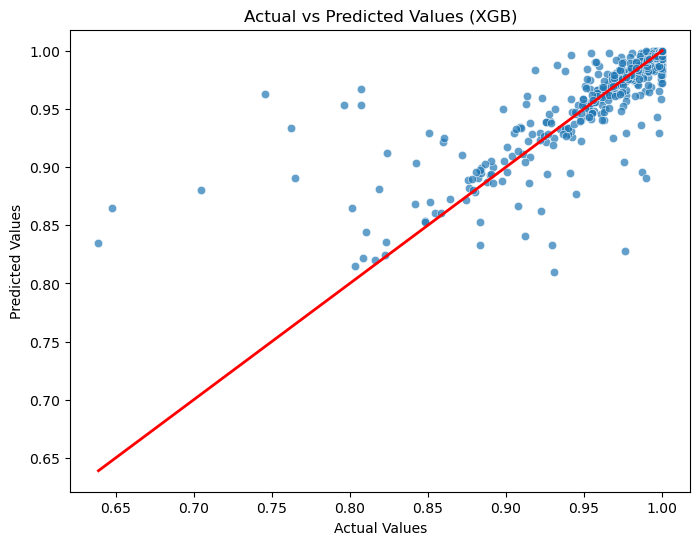

In [77]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
# Add a perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2)
plt.show()


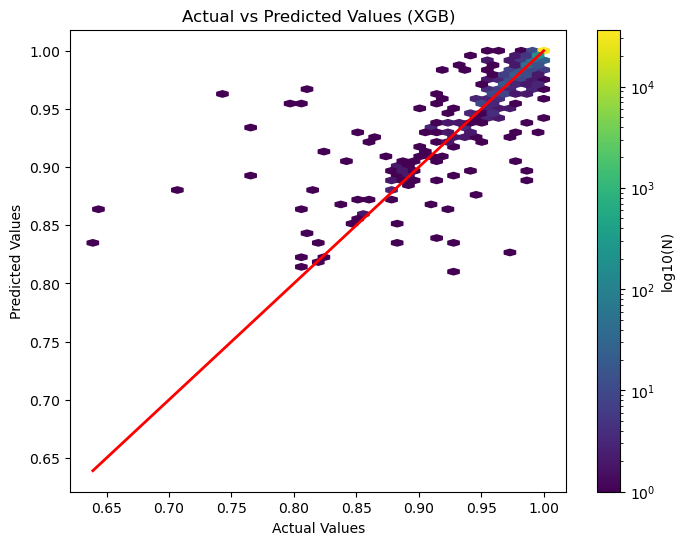

In [78]:
plt.figure(figsize=(8,6))
plt.hexbin(
    y_test.flatten(), 
    y_pred.flatten(), 
    gridsize=40,  # smaller → finer grid
    cmap='viridis', 
    bins='log'  # logarithmic scaling helps emphasize dense areas
)
plt.colorbar(label='log10(N)')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (XGB)")
plt.show()


Insights from the plots 

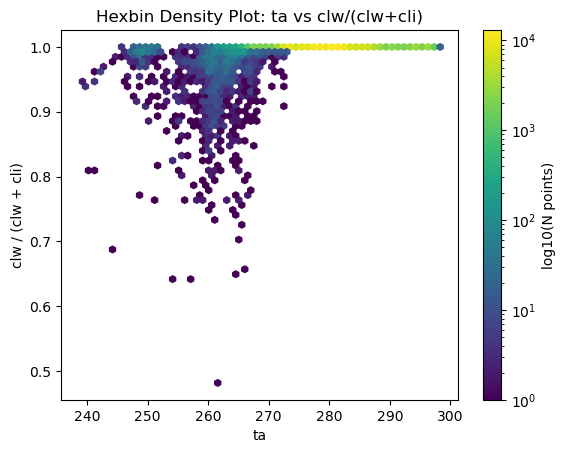

In [80]:
plt.hexbin(
    df['ta'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("ta")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ta vs clw/(clw+cli)")
plt.show()


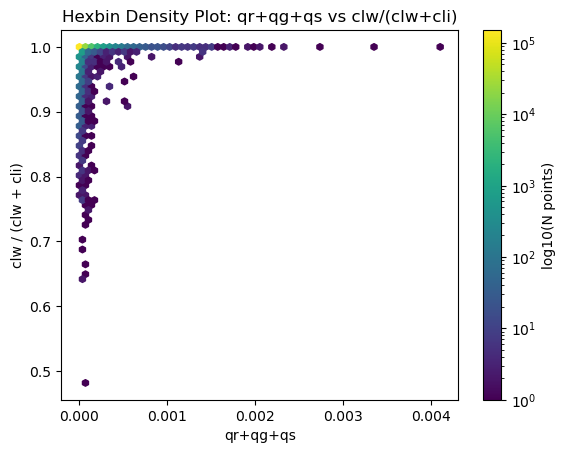

In [83]:
plt.hexbin(
    df['qr+qg+qs'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("qr+qg+qs")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: qr+qg+qs vs clw/(clw+cli)")
plt.show()


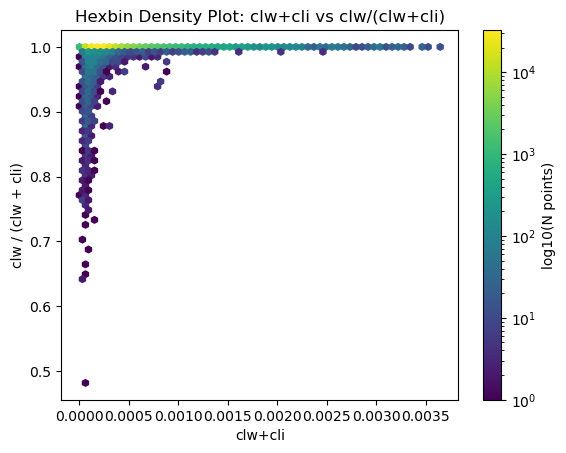

In [84]:
plt.hexbin(
    df['clw+cli'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("clw+cli")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clw+cli vs clw/(clw+cli)")
plt.show()


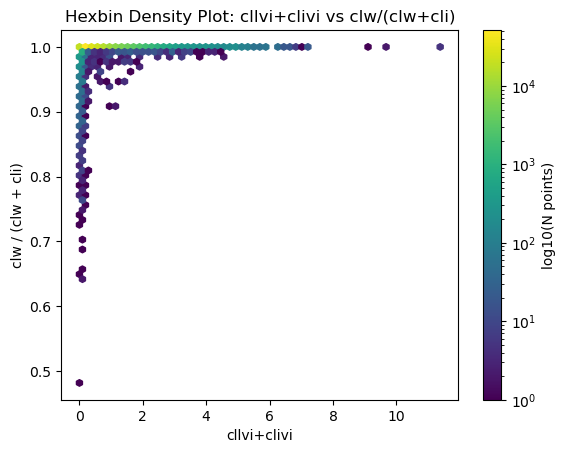

In [85]:
plt.hexbin(
    df['cllvi+clivi'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("cllvi+clivi")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: cllvi+clivi vs clw/(clw+cli)")
plt.show()


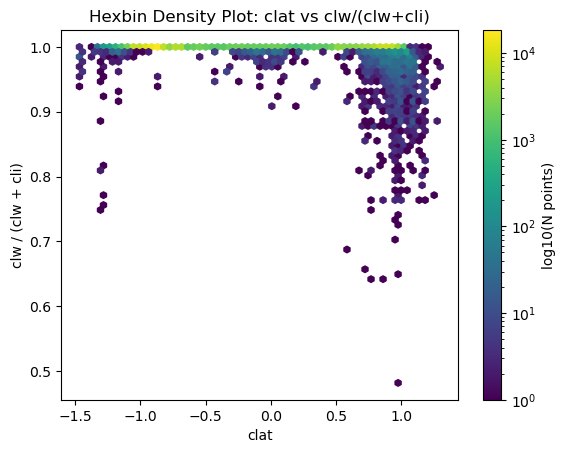

In [86]:
plt.hexbin(
    df['clat'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("clat")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: clat vs clw/(clw+cli)")
plt.show()


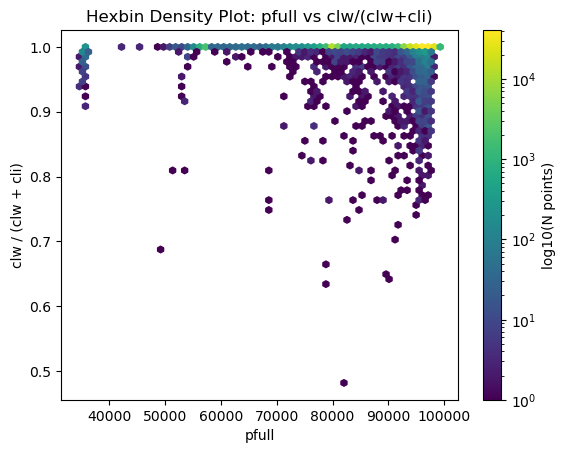

In [87]:
plt.hexbin(
    df['pfull'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("pfull")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: pfull vs clw/(clw+cli)")
plt.show()


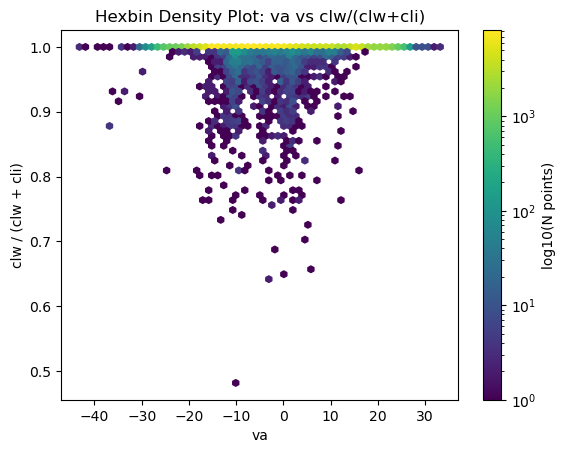

In [89]:
plt.hexbin(
    df['va'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("va")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: va vs clw/(clw+cli)")
plt.show()


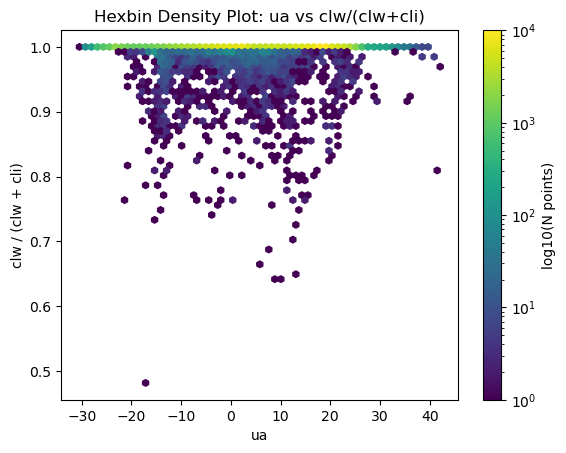

In [90]:
plt.hexbin(
    df['ua'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("ua")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: ua vs clw/(clw+cli)")
plt.show()


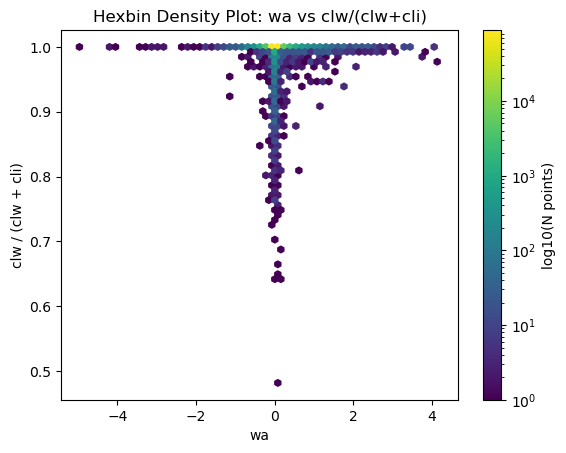

In [88]:
plt.hexbin(
    df['wa'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("wa")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: wa vs clw/(clw+cli)")
plt.show()


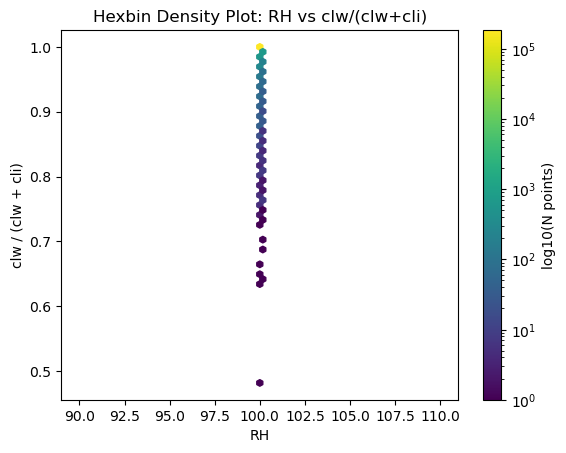

In [91]:
plt.hexbin(
    df['RH'], #[::100]
    df['clw/(clw+cli)'], #[::100]
    gridsize=60,    # adjust resolution (smaller = finer)
    cmap='viridis', # color map
    bins='log'      # use log scale for density
)
plt.colorbar(label='log10(N points)')
# plt.xlim(95, 100)
plt.xlabel("RH")
plt.ylabel("clw / (clw + cli)")
plt.title("Hexbin Density Plot: RH vs clw/(clw+cli)")
plt.show()


In [81]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'm_ci', 'cum_mass', 'qr+qg+qs', 'clw/(clw+cli)',
       'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

BART

In [ ]:
#BART

# bart_condensates = BART(random_state=0, burnin=100, ndraw=15)
# bart_condensates.fit(X_train, y_train)

In [ ]:
# yhat_test = bart_condensates.predict(X_test.astype(np.float32))

# yhat_test = np.clip(yhat_test, 0, 1)
# np.mean((y_test- yhat_test)**2)

In [ ]:
# var_inclusion = pd.Series(bart_condensates.variable_inclusion_.mean(0),
#  index=D.columns)
# var_inclusion

In [79]:
overall_end_time = time.time()

totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

#Total elapsed time is incorrect cuz it defintiely did not take me 188 mins to run this entire code. Probably 45 mins max. 
#More time may be due to parallel processing and thus counting time in multiples and/or waiting period?

The Total Elapsed Time is: 188.0799 minutes
